In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Constants
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 2  # Normal and Pneumonia

In [4]:
# Data Generators with Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [5]:
test_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

In [6]:
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Major_Project_Pneumonia_Detection/D2/train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 4192 images belonging to 2 classes.


In [7]:
test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Major_Project_Pneumonia_Detection/D2/test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Important: Do not shuffle the test data
)

Found 624 images belonging to 2 classes.


In [8]:
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

# Load Pretrained ResNet-50 Model
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# Additional Layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

# Final Classification Layer
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

94765736/94765736 [==============================] - 0s 0us/step


In [9]:
from tensorflow.keras.callbacks import EarlyStopping

# Compile the Model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the Model
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.fit(train_generator, epochs=10, validation_data=test_generator, callbacks=[early_stopping])

Epoch 1/10
131/131 [==============================] - 670s 4s/step - loss: 0.1599 - accuracy: 0.9365 - val_loss: 1.0203 - val_accuracy: 0.6250
Epoch 2/10
131/131 [==============================] - 121s 922ms/step - loss: 0.0808 - accuracy: 0.9699 - val_loss: 0.8425 - val_accuracy: 0.6250
Epoch 3/10
131/131 [==============================] - 118s 897ms/step - loss: 0.0708 - accuracy: 0.9776 - val_loss: 1.9351 - val_accuracy: 0.6250
Epoch 4/10
131/131 [==============================] - 122s 928ms/step - loss: 0.0666 - accuracy: 0.9778 - val_loss: 3.6276 - val_accuracy: 0.6250
Epoch 5/10
131/131 [==============================] - 125s 953ms/step - loss: 0.0545 - accuracy: 0.9800 - val_loss: 5.8371 - val_accuracy: 0.6250
Epoch 6/10
131/131 [==============================] - 125s 955ms/step - loss: 0.0510 - accuracy: 0.9802 - val_loss: 8.6640 - val_accuracy: 0.6250
Epoch 7/10
131/131 [==============================] - 126s 961ms/step - loss: 0.0543 - accuracy: 0.9819 - val_loss: 3.3282 - va

In [ ]:
# model.summary()

In [10]:
# Evaluate the model using the test generator
test_loss, test_accuracy = model.evaluate(test_generator, steps=len(test_generator))
print(f'Test Accuracy: {test_accuracy:.2f}')

# Predict using the model
predictions = model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)

# True labels
true_labels = test_generator.classes

# Calculate accuracy
accuracy = np.sum(predicted_labels == true_labels) / len(true_labels)
print(f'Overall Accuracy: {accuracy:.2f}')

20/20 [==============================] - 7s 303ms/step - loss: 0.8425 - accuracy: 0.6250
Test Accuracy: 0.62
20/20 [==============================] - 9s 380ms/step
Overall Accuracy: 0.62


In [11]:
# Generate and print classification report
report = classification_report(true_labels, predicted_labels, target_names=['Normal', 'Pneumonia'])
print(f'Classification Report:\n{report}')

Classification Report:
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00       234
   Pneumonia       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Confusion Matrix:
[[227   7]
 [118 272]]


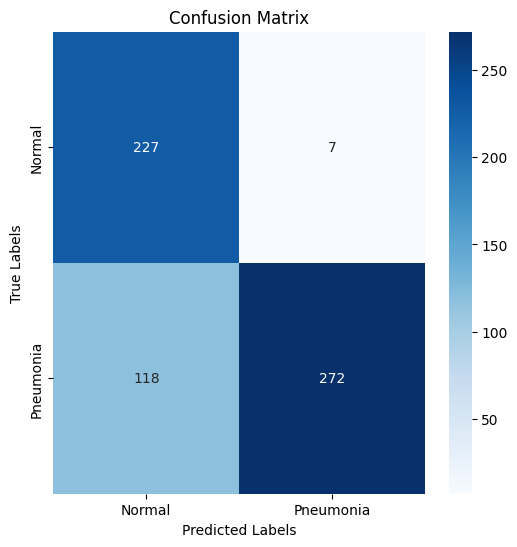

In [ ]:
import seaborn as sns

# Generate and print confusion matrix
matrix = confusion_matrix(true_labels, predicted_labels)
print(f'Confusion Matrix:\n{matrix}')

# Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(matrix, annot=True, fmt='g', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

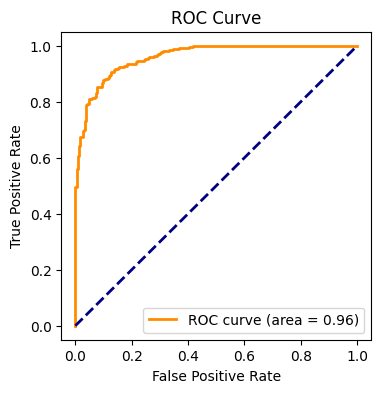

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(true_labels, predictions[:, 1])  # Assuming predictions[:, 1] gives probabilities for the positive class
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# save model
model.save('/content/drive/MyDrive/Major_Project_Pneumonia_Detection/models/pneumonia_resnet_extra_layers.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input, decode_predictions
import numpy as np

In [ ]:
# Load the trained model
model = tf.keras.models.load_model('/content/drive/MyDrive/Major_Project_Pneumonia_Detection/models/pneumonia_resnet_extra_layers.h5')

In [ ]:
# Function to preprocess the user input image
def preprocess_image(image_path):
    img = image.load_img(image_path, target_size=IMAGE_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

In [ ]:
# Take input image path from the user
input_image_path = input("Enter the path to the image you want to classify: ")

try:
    # Preprocess the input image
    input_img_array = preprocess_image(input_image_path)

    # Perform prediction
    predictions = model.predict(input_img_array)
    class_labels = ['Normal', 'Pneumonia']
    predicted_class_index = np.argmax(predictions)
    predicted_class = class_labels[predicted_class_index]
    confidence = predictions[0][predicted_class_index] * 100

    # Display the prediction
    print(f"The input image is classified as {predicted_class} with confidence {confidence:.2f}%.")

except Exception as e:
    print(f"Error: {e}")




Enter the path to the image you want to classify: /content/drive/MyDrive/Major_Project_Pneumonia_Detection/D2/test/normal/IM-0003-0001.jpeg
1/1 [==============================] - 0s 35ms/step
The input image is classified as Pneumonia with confidence 100.00%.
